# 02 — Exploratory Data Analysis

This notebook answers the main business questions using the cleaned project datasets.

Where repeated appearances would distort interpretation, the notebook uses the video-level table rather than raw row counts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(".")
row_df = pd.read_csv(BASE_DIR / "yt_project_outputs" / "analysis_row_level.csv", parse_dates=["snapshot_date", "publish_date"])
video_df = pd.read_csv(BASE_DIR / "yt_project_outputs" / "analysis_video_level.csv", parse_dates=["first_snapshot_date", "publish_date"])

print(row_df.shape, video_df.shape)

(148567, 34) (91033, 25)


## 1) What is the average likes-to-views ratio across trending videos?

In [2]:
ratio_summary = row_df["likes_to_views_ratio"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(4)
ratio_summary

count    148535.0000
mean          0.0405
std           0.0324
min           0.0000
25%           0.0173
50%           0.0324
75%           0.0545
90%           0.0808
95%           0.1008
max           1.0030
Name: likes_to_views_ratio, dtype: float64

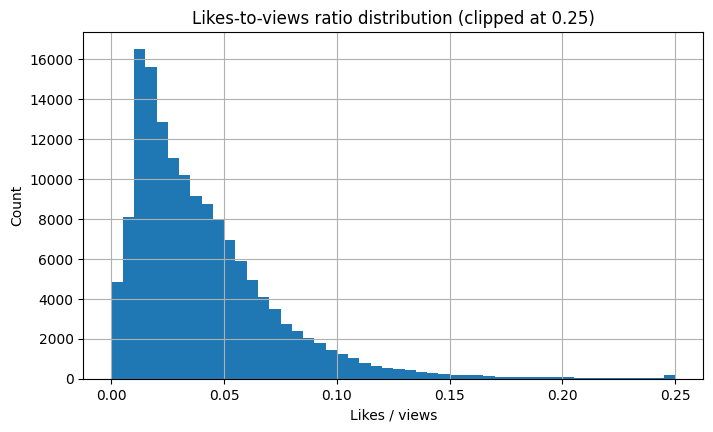

In [3]:
plt.figure(figsize=(8, 4.5))
row_df["likes_to_views_ratio"].clip(upper=0.25).hist(bins=50)
plt.title("Likes-to-views ratio distribution (clipped at 0.25)")
plt.xlabel("Likes / views")
plt.ylabel("Count")
plt.show()

## 2) Is there a view-count threshold at which videos typically appear in trending?

In [4]:
first_entry = row_df.sort_values("snapshot_date").groupby(["video_id", "country"]).first().reset_index()
first_entry["view_count"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5]).round(0)

count       129647.0
mean      10487981.0
std       23177968.0
min              0.0
1%           19615.0
5%           70975.0
10%         128871.0
25%         355338.0
50%        1445307.0
max      449806738.0
Name: view_count, dtype: float64

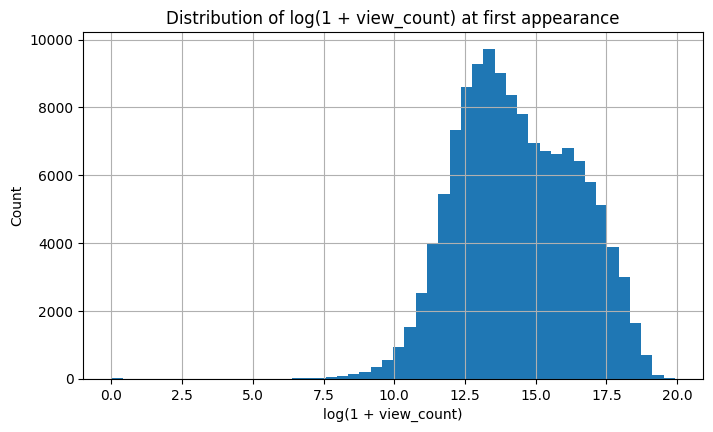

In [5]:
first_entry["log_view_count"] = np.log1p(first_entry["view_count"])
plt.figure(figsize=(8, 4.5))
first_entry["log_view_count"].hist(bins=50)
plt.title("Distribution of log(1 + view_count) at first appearance")
plt.xlabel("log(1 + view_count)")
plt.ylabel("Count")
plt.show()

## 3) Is there any relationship between language and global trending reach?

In [6]:
language_global = (
    video_df.groupby("language_clean")
    .agg(
        videos=("video_id", "count"),
        avg_country_span=("country_span", "mean"),
        median_country_span=("country_span", "median"),
        median_engagement=("median_engagement_rate", "median"),
    )
    .query("videos >= 1000")
    .sort_values("avg_country_span", ascending=False)
)
language_global.head(15).round(3)

,videos,avg_country_span,median_country_span,median_engagement
language_clean,,,,
en,20873,2.593,1.0,0.029
ko,1888,2.125,1.0,0.026
es,8620,2.110,1.0,0.035
ar,6081,2.054,1.0,0.046
unknown,18920,1.897,1.0,0.032
zh,2706,1.704,1.0,0.020
ru,3062,1.520,1.0,0.035
hi,1216,1.348,1.0,0.025
ja,1407,1.265,1.0,0.028


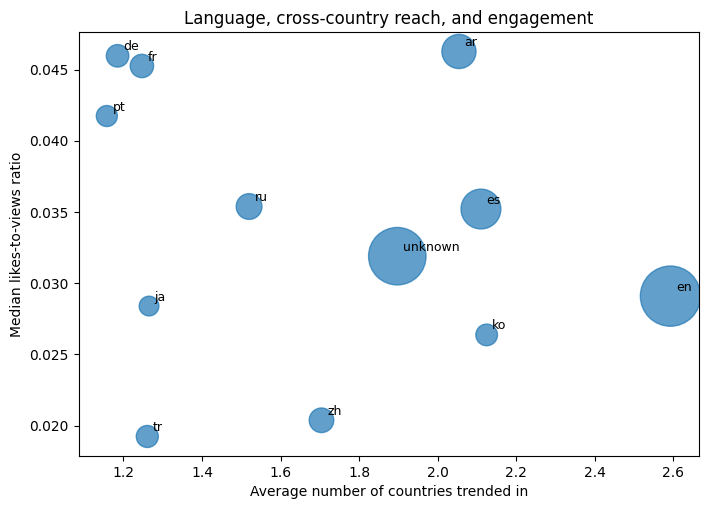

In [7]:
top_lang = (
    language_global.reset_index()
    .sort_values("videos", ascending=False)
    .head(12)
)

plt.figure(figsize=(8, 5.5))
sizes = (top_lang["videos"] / top_lang["videos"].max()) * 1800 + 80
plt.scatter(top_lang["avg_country_span"], top_lang["median_engagement"], s=sizes, alpha=0.7)
for _, r in top_lang.iterrows():
    plt.annotate(r["language_clean"], (r["avg_country_span"], r["median_engagement"]),
                 xytext=(4, 4), textcoords="offset points", fontsize=9)
plt.title("Language, cross-country reach, and engagement")
plt.xlabel("Average number of countries trended in")
plt.ylabel("Median likes-to-views ratio")
plt.show()

## 4) Do videos with longer descriptions tend to have higher engagement?

In [8]:
video_df["desc_len_bin"] = pd.cut(
    video_df["description_length"],
    bins=[-1, 0, 100, 300, 600, 1200, 100000],
    labels=["0", "1-100", "101-300", "301-600", "601-1200", "1201+"]
)

desc_summary = (
    video_df.groupby("desc_len_bin", observed=False)
    .agg(
        videos=("video_id", "count"),
        median_engagement=("median_engagement_rate", "median"),
        mean_engagement=("avg_engagement_rate", "mean"),
    )
)
desc_summary.round(4)

,videos,median_engagement,mean_engagement
desc_len_bin,,,
0,10956,0.0348,0.0397
1-100,5407,0.0336,0.0413
101-300,14220,0.0287,0.0390
301-600,20429,0.0343,0.0434
601-1200,21501,0.0304,0.0397
1201+,18520,0.0277,0.0377


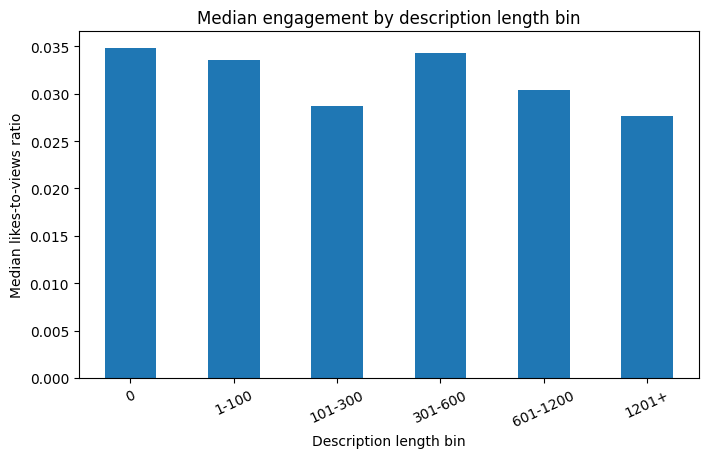

In [9]:
plt.figure(figsize=(8, 4.5))
desc_summary["median_engagement"].plot(kind="bar")
plt.title("Median engagement by description length bin")
plt.xlabel("Description length bin")
plt.ylabel("Median likes-to-views ratio")
plt.xticks(rotation=25)
plt.show()

## 5) Are videos published on certain days of the week more likely to have higher engagement?

In [10]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = (
    video_df.groupby("publish_weekday")
    .agg(
        videos=("video_id", "count"),
        median_engagement=("median_engagement_rate", "median"),
        mean_engagement=("avg_engagement_rate", "mean"),
    )
    .reindex(day_order)
)
weekday_summary.round(4)

,videos,median_engagement,mean_engagement
publish_weekday,,,
Monday,12040,0.0317,0.0405
Tuesday,12343,0.0316,0.0403
Wednesday,12673,0.0315,0.0405
Thursday,14025,0.0317,0.0407
Friday,15067,0.0336,0.0426
Saturday,12228,0.0286,0.0377
Sunday,12657,0.0290,0.0380


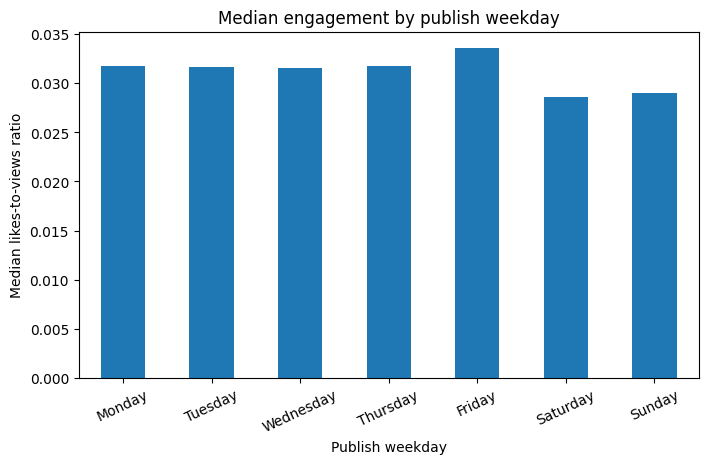

In [11]:
plt.figure(figsize=(8, 4.5))
weekday_summary["median_engagement"].plot(kind="bar")
plt.title("Median engagement by publish weekday")
plt.xlabel("Publish weekday")
plt.ylabel("Median likes-to-views ratio")
plt.xticks(rotation=25)
plt.show()

## 6) How long after publish date do most videos enter trending?

In [12]:
lag_summary = video_df["days_to_first_trend"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(2)
lag_summary

count    91033.00
mean         4.24
std          4.15
min          0.00
10%          1.00
25%          2.00
50%          3.00
75%          6.00
90%          9.00
95%         12.00
max         37.00
Name: days_to_first_trend, dtype: float64

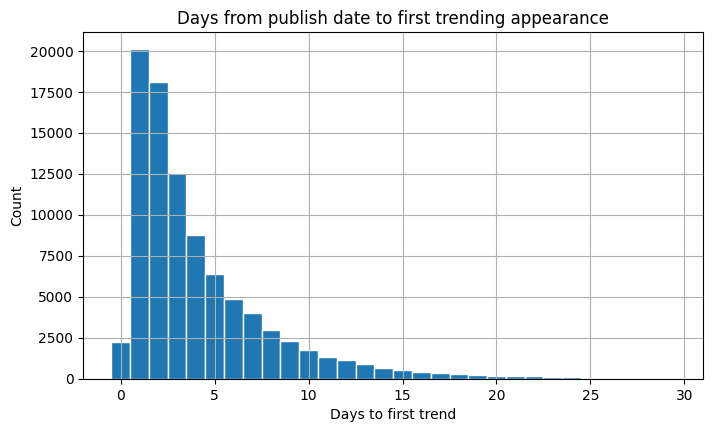

In [13]:
valid_lag = video_df["days_to_first_trend"].dropna()
valid_lag = valid_lag[(valid_lag >= 0) & (valid_lag <= 30)]

plt.figure(figsize=(8, 4.5))
valid_lag.hist(bins=np.arange(-0.5, 30.5, 1), edgecolor="white")
plt.title("Days from publish date to first trending appearance")
plt.xlabel("Days to first trend")
plt.ylabel("Count")
plt.show()

## 7) What kind of language tends to give better engagement?

In [14]:
style_summary = pd.DataFrame({
    "metric": ["uppercase_ratio", "exclamation_count", "question_count", "title_length", "description_length"],
    "correlation_with_avg_engagement": [
        video_df["uppercase_ratio"].corr(video_df["avg_engagement_rate"]),
        video_df["exclamation_count"].corr(video_df["avg_engagement_rate"]),
        video_df["question_count"].corr(video_df["avg_engagement_rate"]),
        video_df["title_length"].corr(video_df["avg_engagement_rate"]),
        video_df["description_length"].corr(video_df["avg_engagement_rate"]),
    ]
}).round(4)

style_summary

,metric,correlation_with_avg_engagement
0,uppercase_ratio,0.0761
1,exclamation_count,0.0638
2,question_count,0.0220
3,title_length,-0.1587
4,description_length,-0.0232


## Summary

Three patterns stand out:

1. Most videos that eventually trend do so very quickly, usually within the first week.
2. Friday publishes have the strongest median engagement among the seven weekdays.
3. Language appears related to both cross-country spread and engagement, with English widest in spread and Arabic/Spanish notably strong on engagement within this sample.

These are associations within the trending sample, not causal claims about YouTube overall.